best l1_ratio: 1.0, best alpha: 0.0467322918527008
MSE: 3072.0506800286353


Text(0, 0.5, 'True')

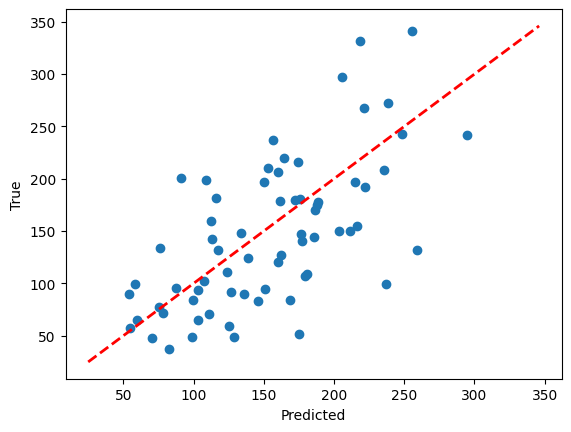

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import ElasticNetCV
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error

import pandas as pd

np.random.seed(123)

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

data = np.hstack((diabetes.data, diabetes.target.reshape(-1, 1)))

# Train/Test Split
train_size = int(data.shape[0] * 0.85)
train_indices = np.random.choice(data.shape[0], size=train_size, replace=False)
test_indices = np.setdiff1d(np.arange(data.shape[0]), train_indices)

train_set = data[train_indices, :]
test_set = data[test_indices, :]



X = train_set[:,:9]
y = train_set[:,10]


X_test = test_set[:,:9]
y_test = test_set[:,10]


pipe = Pipeline([("scale", StandardScaler()), 
                 ("model", ElasticNetCV(l1_ratio=np.linspace(0.001, 1, 5), cv=5))])

# pipe.get_params()

pipe.fit(X,y)

fitted = pipe.named_steps['model']

print(f"best l1_ratio: {fitted.l1_ratio_}, best alpha: {fitted.alpha_}")

pred = pipe.predict(X_test)

mse = mean_squared_error(y_test, pred)
print(f"MSE: {mse}")

plt.scatter(pred, y_test)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Predicted')
plt.ylabel('True')

Best l1_ratio, best alpha for EN = 0.0021, 0.9000
test data fitting


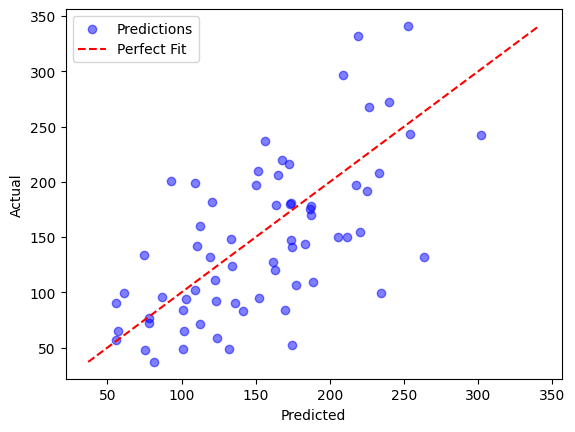

test data MSE: 3083.5235


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

"""
We have created a linear regression algorithm, now we will create more advanced regularised regression algorithms such as Ridge, Lasso
and Elastic net.
Data needs to be standardised.
"""
np.random.seed(123)

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

# Combine X (features) and y (target)
data = np.hstack((diabetes.data, diabetes.target.reshape(-1, 1)))

# Train/Test Split
train_size = int(data.shape[0] * 0.85)
train_indices = np.random.choice(data.shape[0], size=train_size, replace=False)
test_indices = np.setdiff1d(np.arange(data.shape[0]), train_indices)

train_set = data[train_indices, :]
test_set = data[test_indices, :]

"""
We will use similar functions as to the previous regression class but slightly modified.
"""


class Regression:
    def __init__(self, data, observer, predictor, lambd, order = 1, epsilon = 0, alpha=0.5, initial_beta = np.array([1])):
        self.obs = observer
        self.pred = predictor
        self.lambd = lambd
        self.alpha = alpha
        self.beta = initial_beta
        self.epsilon = epsilon
        self.order = order

        if type(self.obs) == int: #allow for multidimensional input
                self.data = data[:, [self.obs, self.pred]]
        
        else:
            index = self.obs + [self.pred]
            self.data = data[:, index]

        self.pred_pos = (self.data.shape[1] - 1)
        self.obs_pos = np.arange(self.pred_pos)

        #Polynomail model requirement
        self.pred_pos_original = self.pred_pos
        self.obs_pos_original = self.obs_pos

        if self.order > 1:
                x = self.data[:, self.obs_pos]
                y = self.data[:, self.pred_pos].reshape(-1, 1)
                
                x_poly = self.create_poly_features(x)
                self.data = np.hstack((x_poly, y))
                
                # Update positions because we just added a bunch of columns!
                self.pred_pos = (self.data.shape[1] - 1)
                self.obs_pos = np.arange(self.pred_pos)
        
        #Store the raw data safely
        self.raw_data = np.asarray(self.data, dtype=float)
        
        #Initialize scaling metrics
        self.mean_vals = None
        self.std_vals = None
        self.data = None 
        
        #Scale the full dataset initially (if we choose to not use CV)
        self.scale_and_set_data(self.raw_data)

    def scale_and_set_data(self, raw_data_subset):
        """
        Calculates mean and std on the provided subset ONLY, 
        and updates self.data with the scaled version.
        """
        self.mean_vals = np.mean(raw_data_subset, axis=0)
        self.std_vals = np.std(raw_data_subset, axis=0) + 1e-8
        
        self.data = (raw_data_subset - self.mean_vals) / self.std_vals


    def create_poly_features(self, x):
            x_poly = x.copy()
            for i in range(2, self.order + 1):
                x_poly = np.hstack((x_poly, np.power(x, i)))
            return(x_poly)

    def combine_int(self, data): #function to combine intercept to data
            p = data.shape[0] 
            intercept = np.ones((p, 1))
            
    
            Data_new= np.hstack((intercept, data))
            return(Data_new)
    
    def min_SSR(self):
        x = np.asarray(self.data[:,self.obs_pos], dtype=float)
        y = np.asarray(self.data[:,self.pred_pos], dtype=float).reshape(1,-1)
    
        x = self.combine_int(x)
    
    
        b_hat = (np.linalg.inv((x.T @ x))) @ (x.T @ y)
        return(b_hat)


    def Ridge(self):
        x = np.asarray(self.data[:,self.obs_pos], dtype=float)
        x = self.combine_int(x)
        y = np.asarray(self.data[:,self.pred_pos], dtype=float)

        I = np.eye(x.shape[1])
        I[0,0] = 0 #Do not want lambda to act on the intercept

        n = self.data.shape[0]

        b_hat = np.linalg.inv((x.T @ x) + (n*self.lambd*I)) @ (x.T @ y)
        self.beta = b_hat
        # print(f"Ridge beta value of {b_hat}")
        return(b_hat)


    def lasso(self, iterations = 1000): #requires iteration in order to update beta to the optimal coefficient vector, most libraries will use coordinate descent
        # we will use this process however to save time will obtain the nested loop from AI.
        x = self.combine_int(self.data[:,self.obs_pos])

        self.beta = np.zeros(x.shape[1])

        # Coordinate Descent Loop
        for _ in range(iterations):
            for j in range(x.shape[1]):
                # Temporarily remove the current feature's weight
                tmp_weights = self.beta.copy()
                tmp_weights[j] = 0.0
                
                #  Calculate the residual error
                l = self.data[:,self.pred_pos] - (x @ tmp_weights)
                
                # Calculate the correlation between this feature and the error (determining how useful the feature if for the regression)
                rho = (x[:, j] @ l) / x.shape[0]
                
                # The Soft Thresholding solution
                if j ==0:
                     self.beta[j] = rho
                elif rho < -self.lambd:
                    self.beta[j] = rho + self.lambd
                elif rho > self.lambd:
                    self.beta[j] = rho - self.lambd
                else:
                    self.beta[j] = 0.0 # Snaps to zero

        b_hat = self.beta
        # print(f"Lasso beta value of {b_hat}")
        return(b_hat)

    def elastic_net(self, iterations=1000, tol=1e-4):
        x = self.combine_int(self.data[:, self.obs_pos])
        y = self.data[:, self.pred_pos]
        
        n_samples, n_features = x.shape
        self.beta = np.zeros(n_features)
        
        l1 = self.lambd * self.alpha
        l2 = self.lambd * (1 - self.alpha)

        # Squared sum of each feature
        #(x_j^T @ x_j) / N
        x_squared_sums = (x ** 2).sum(axis=0) / n_samples
        
        #Running residual used to reduce run time (suggested by AI)
        r = y - (x @ self.beta) 

        # Coordinate Descent Loop as above
        for i in range(iterations):
            max_weight_change = 0.0
            
            for j in range(n_features):
                old_beta_j = self.beta[j]
                
                #Faster Rho calculation as oppsed to previous: 
                #Calculate rho using the running residual + the current feature's isolated contribution.
                rho = (x[:, j] @ r) / n_samples + (x_squared_sums[j] * old_beta_j)
                
                if j == 0: #Intercept
                    self.beta[j] = rho / x_squared_sums[j]
                else:
                    # Soft thresholding as above
                    if rho < -l1:
                        beta_j = rho + l1
                    elif rho > l1:
                        beta_j = rho - l1
                    else:
                        beta_j = 0.0 
                        
                    #Same as above but not assuming standardised (more of a precaution)
                    self.beta[j] = beta_j / (x_squared_sums[j] + l2)
                
                #Update running residual only if the weight actually changed
                weight_change = self.beta[j] - old_beta_j
                if weight_change != 0:
                    r = r - (x[:, j] * weight_change)
                    
                # Track the largest change in weights for convergence
                max_weight_change = max(max_weight_change, abs(weight_change))
                
            #Convergence Check
            if max_weight_change < tol:
                # print(f"Converged early at iteration {i}")
                break

        b_hat = self.beta
        return b_hat



    def predict(self, x):
        x = self.combine_int(x)
        return(x @ self.beta + self.epsilon)


    def plot_model(self, data=None):
        if data is None:
            data = self.data
            
        #Determine if we are looking at scaled internal data, or raw external data for when apply to test data (idea taken from AI)
        is_internal = np.array_equal(data, self.data)
            
        if type(self.obs) == int:
            if is_internal:
                # internal data is scaled, and Y has been pushed to the end (self.pred_pos)
                x = (data[:, 0] * self.std_vals[0]) + self.mean_vals[0]
                y = (data[:, self.pred_pos] * self.std_vals[self.pred_pos]) + self.mean_vals[self.pred_pos]
            else:
                # test data is completely raw and unscaled
                x = data[:, self.obs_pos_original]
                y = data[:, self.pred_pos_original]

            plt.scatter(x, y, color="blue", label="Actual Data")

            x_smooth = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

            # Expanding and scaling the smooth line for predictions
            if self.order > 1:
                x_smooth_poly = self.create_poly_features(x_smooth)
                x_smooth_scaled = (x_smooth_poly - self.mean_vals[self.obs_pos]) / self.std_vals[self.obs_pos]

            else:
                x_smooth_scaled = (x_smooth - self.mean_vals[self.obs_pos]) / self.std_vals[self.obs_pos]

            data_y_smooth_scaled = self.predict(x_smooth_scaled)
            
            # Unscaling the predictions back to realistic data
            data_y_smooth = (data_y_smooth_scaled * self.std_vals[self.pred_pos]) + self.mean_vals[self.pred_pos]

            plt.plot(data_y_smooth,  x_smooth, color="red", label="Regression Line")
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.legend()
            plt.show()

        else:
            if is_internal:
                x_input = data[:, self.obs_pos]
                y_actual_scaled = data[:, self.pred_pos]
            else:
                x_raw = data[:, self.obs_pos_original]
                y_raw = data[:, self.pred_pos_original]

                if self.order > 1:
                    x_input = self.create_poly_features(x_raw)
                else:
                    x_input = x_raw

                x_input = (x_input - self.mean_vals[self.obs_pos]) / self.std_vals[self.obs_pos]
                y_actual_scaled = (y_raw - self.mean_vals[self.pred_pos]) / self.std_vals[self.pred_pos]

            data_y_scaled = self.predict(x_input)
            
            data_y = (data_y_scaled * self.std_vals[self.pred_pos]) + self.mean_vals[self.pred_pos]
            y = (y_actual_scaled * self.std_vals[self.pred_pos]) + self.mean_vals[self.pred_pos]
            
            plt.scatter(data_y.flatten(), y.flatten(), color="blue", alpha=0.5, label="Predictions")

            min_val = min(y.min(), data_y.min())
            max_val = max(y.max(), data_y.max())
            plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Fit")

            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.legend()
            plt.show()

    def mse(self, x, y):
        if self.order > 1:
            x_input = self.create_poly_features(x)
        else:
            x_input = x

        #Need to scale the input features using the training mean/std, within function to prevent leakage
        x_scaled = (x_input - self.mean_vals[self.obs_pos]) / self.std_vals[self.obs_pos]

        
        y_pred_scaled = self.predict(x_scaled)

        #Unscale the predictions
        y_pred = (y_pred_scaled * self.std_vals[self.pred_pos]) + self.mean_vals[self.pred_pos]
        
        return np.mean((y - y_pred.flatten()) ** 2)

    """
    Let us now emplopy hyperparamter selection to find the optimal lambda and alpha vlaues, in particular we will use K fold cross validation.
    """
    def K_fold_CV(self, method, k=5): 
        # Utilise raw data to prevent leakage
        original_raw_data = self.raw_data.copy() 
        n = original_raw_data.shape[0]
        
        indices = np.random.permutation(n)
        folds = np.array_split(indices, k)

        #Logarithmic spacing for lambda (Default used in SKlearn)
        hyp_cand_lamb = np.logspace(-4, 1, 20) 
        hyp_cand_lamb = np.append(hyp_cand_lamb, [0.0])
        
        #Sklearn's standard l1_ratios for a fair comparison
        hyp_cand_alpha = np.array([0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0])

        mse_scores = {(l, a): [] for l in hyp_cand_lamb for a in hyp_cand_alpha}

        for valid_idx in folds:
            train_idx = np.setdiff1d(indices, valid_idx)
            
            for l in hyp_cand_lamb:
                for a in hyp_cand_alpha:
                    self.lambd = l
                    self.alpha = a
                    
                    # Scale training fold
                    train_fold_raw = original_raw_data[train_idx]
                    self.scale_and_set_data(train_fold_raw)
                    
                    #Fit the model
                    if method in ["EN", "elastic net", "Elastic net", "en", "Elastic Net"]:
                        self.elastic_net()
                    elif method in ["Ridge", "ridge"]:
                        self.Ridge()
                    else:
                        self.lasso()

                    #Calculate MSE on the UNSCALED target data
                    valid_fold_raw = original_raw_data[valid_idx]
                    
                    # Scale only the input features for prediction
                    x_valid_raw = valid_fold_raw[:, self.obs_pos_original]
                    
                    if self.order > 1:
                        x_valid_input = self.create_poly_features(x_valid_raw)
                    else:
                        x_valid_input = x_valid_raw
                        
                    x_valid_scaled = (x_valid_input - self.mean_vals[self.obs_pos]) / self.std_vals[self.obs_pos]
                    
                    # Generate scaled predictions
                    y_valid_pred_scaled = self.predict(x_valid_scaled)
                    
                    # Unscale the predictions back to real-world values
                    y_valid_pred = (y_valid_pred_scaled * self.std_vals[self.pred_pos]) + self.mean_vals[self.pred_pos]
                    
                    # Compare against the RAW actual target
                    y_actual_raw = valid_fold_raw[:, self.pred_pos_original]
                    
                    fold_mse = np.mean((y_actual_raw - y_valid_pred.flatten()) ** 2)
                    mse_scores[(l, a)].append(fold_mse)

                    if method not in ["EN", "elastic net", "Elastic net", "en", "Elastic Net"]:
                        break
        
        # Finding the best hyperparameters
        best_lambda, best_alpha = None, None
        min_avg_mse = float('inf')

        for (l, a), scores in mse_scores.items():
            if not scores:
                continue

            avg_mse = np.mean(scores)
            if avg_mse < min_avg_mse:
                min_avg_mse = avg_mse
                best_lambda = l
                best_alpha = a
        
        self.lambd = best_lambda
        self.alpha = best_alpha
        
        # Re-scale using entire dataset before final fit
        self.scale_and_set_data(original_raw_data)
        
        if method in ["EN", "elastic net", "Elastic net", "en", "Elastic Net"]:
            self.elastic_net()
            print(f"Best l1_ratio, best alpha for {method} = {best_lambda:.4f}, {best_alpha:.4f}")
        elif method in ["Ridge", "ridge"]:
            self.Ridge()
            print(f"Optimal lambda for {method} = {best_lambda:.4f}")
        else:
            self.lasso()
            print(f"Optimal lambda for {method} = {best_lambda:.4f}")
        
    
if __name__ == "__main__":
    my_model = Regression(data=train_set, epsilon=1e-3, order=1, predictor=10, observer=[0,1,2,3,4,5,6,7,8,9], lambd=0.5, alpha=0.5)                            
    my_model.K_fold_CV(method="EN", k=5)

    print("test data fitting")
    
    if isinstance(my_model.obs, int):
        X_test = test_set[:, my_model.obs].reshape(-1, 1)  # Force 1D into 2D
    else:
        X_test = test_set[:, my_model.obs] 

    my_model.plot_model(data=test_set)

    y_test = test_set[:, my_model.pred]
    
    print(f"test data MSE: {my_model.mse(X_test, y_test):.4f}")
    
    
    #my_model.plot_model(data=test_set)

Here I have compared SKlearns ElsaticNetCV to my own NumPy K-fold CV version. Both utilised the Diabetes dataset from SKlearn. My model competed well against the SKlearn model with only ~0.3% difference in MSE. The difference in selected hyperparameters can be attributed to the complexity of the SKlearn model allowing for specific alpha value generation, as opposed to my specified list of possible values (which I opted for the SKlearn default values). 